### AF2BIND: Prediction of ligand-binding sites using AlphaFold2

AF2BIND is a simple and fast notebook that runs inference on the output obtained from [AlphaFold2](https://github.com/deepmind/alphafold).

<!--<img src="https://raw.githubusercontent.com/artemg97/af2bind_prod/main/logo.png" width="300">.-->

<figure>
<img src='https://raw.githubusercontent.com/artemg97/af2bind_prod/main/logo.png'  width="300" height="150"/>
</figure>



For more details see preprint:

**AF2BIND: Predicting ligand-binding sites using the pair representation of AlphaFold2**
* Artem Gazizov, Anna Lian, Casper Alexander Goverde, Sergey Ovchinnikov, Nicholas F. Polizzi
* https://doi.org/10.1101/2023.10.15.562410


In [ ]:
%%time
#@title Install AlphaFold2 (~2 mins)
#@markdown Please execute this cell by pressing the *Play* button on
#@markdown the left.
import os, time
if not os.path.isdir("params"):
  # get code
  print("installing ColabDesign")
  os.system("(mkdir params; apt-get install aria2 -qq; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2021-07-14.tar; \
  mkdir af2bind_params; \
  wget -qnc https://github.com/sokrypton/af2bind/raw/main/attempt_7_2k_lam0-03.zip; unzip attempt_7_2k_lam0-03.zip -d af2bind_params; \
  tar -xf alphafold_params_2021-07-14.tar -C params; touch params/done.txt )&")

  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@v1.1.1")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")

  # download params
  if not os.path.isfile("params/done.txt"):
    print("downloading params")
    while not os.path.isfile("params/done.txt"):
      time.sleep(5)

import os
from colabdesign import mk_afdesign_model, clear_mem
from IPython.display import HTML
from google.colab import files
import numpy as np

from colabdesign.af.alphafold.common import residue_constants
import pandas as pd
from google.colab import data_table
data_table._DEFAULT_FORMATTERS[float] = lambda x: f"{x:.3f}"
from IPython.display import display, HTML
import jax, pickle
import jax.numpy as jnp
from scipy.special import expit as sigmoid
import plotly.express as px

import py3Dmol
import matplotlib.pyplot as plt
from scipy.special import softmax
import copy
from colabdesign.shared.protein import renum_pdb_str
from colabdesign.af.alphafold.common import protein


aa_order = {v:k for k,v in residue_constants.restype_order.items()}

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.system(f"wget -qnc https://files.rcsb.org/view/{pdb_code}.pdb")
    pdb_path = f"{pdb_code}.pdb"
    if not os.path.isfile(pdb_path):
      raise FileNotFoundError(
        f"Could not download PDB structure for '{pdb_code}' from RCSB. "
        f"Please check the PDB ID is correct."
      )
    return pdb_path
  else:
    # Try AlphaFold DB with multiple model versions (v4 -> v3 -> v2)
    for version in ("v4", "v3", "v2"):
      fname = f"AF-{pdb_code}-F1-model_{version}.pdb"
      if os.path.isfile(fname):
        return fname
      url = f"https://alphafold.ebi.ac.uk/files/{fname}"
      ret = os.system(f"wget -q {url} -O {fname}")
      if ret == 0 and os.path.isfile(fname) and os.path.getsize(fname) > 100:
        print(f"Downloaded AlphaFold structure: {fname}")
        return fname
      # wget failed or file is empty/error page — clean up
      if os.path.isfile(fname):
        os.remove(fname)

    raise FileNotFoundError(
      f"Could not download AlphaFold structure for UniProt ID '{pdb_code}'. "
      f"This protein may not be in the AlphaFold Database. "
      f"Try using a 4-letter PDB ID instead (e.g. 1ZNI), or check "
      f"https://alphafold.ebi.ac.uk/ to verify the ID exists."
    )

def af2bind(outputs, mask_sidechains=True, seed=0):
  pair_A = outputs["representations"]["pair"][:-20,-20:]
  pair_B = outputs["representations"]["pair"][-20:,:-20].swapaxes(0,1)
  pair_A = pair_A.reshape(pair_A.shape[0],-1)
  pair_B = pair_B.reshape(pair_B.shape[0],-1)
  x = np.concatenate([pair_A,pair_B],-1)

  # get params
  if mask_sidechains:
    model_type = f"split_nosc_pair_A_split_nosc_pair_B_{seed}"
  else:
    model_type = f"split_pair_A_split_pair_B_{seed}"
  with open(f"af2bind_params/attempt_7_2k_lam0-03/{model_type}.pickle","rb") as handle:
    params_ = pickle.load(handle)
  params_ = dict(**params_["~"], **params_["linear"])
  p = jax.tree_util.tree_map(lambda x:np.asarray(x), params_)

  # get predictions
  x = (x - p["mean"]) / p["std"]
  x = (x * p["w"][:,0]) + (p["b"] / x.shape[-1])
  p_bind_aa = x.reshape(x.shape[0],2,20,-1).sum((1,3))
  p_bind = sigmoid(p_bind_aa.sum(-1))
  return {"p_bind":p_bind, "p_bind_aa":p_bind_aa}

In [6]:
#@title **Run AF2BIND** 🔬
target_pdb = "Q6DG85" #@param {type:"string"}
target_chain = "A" #@param {type:"string"}
#@markdown - Please indicate target pdb (or uniprot ID to download from AlphaFoldDB) and chain.
#@markdown - Leave pdb blank for custom upload prompt.
mask_sidechains = True
mask_sequence = False

target_pdb = target_pdb.replace(" ","")
target_chain = target_chain.replace(" ","")
if target_chain == "":
  target_chain = "A"

pdb_filename = get_pdb(target_pdb)

clear_mem()
af_model = mk_afdesign_model(protocol="binder", debug=True)
af_model.prep_inputs(pdb_filename=pdb_filename,
                     chain=target_chain,
                     binder_len=20,
                     rm_target_sc=mask_sidechains,
                     rm_target_seq=mask_sequence)

# split
r_idx = af_model._inputs["residue_index"][-20] + (1 + np.arange(20)) * 50
af_model._inputs["residue_index"][-20:] = r_idx.flatten()

af_model.set_seq("ACDEFGHIKLMNPQRSTVWY")
af_model.predict(verbose=False)

o = af2bind(af_model.aux["debug"]["outputs"],
            mask_sidechains=mask_sidechains)
pred_bind = o["p_bind"].copy()
pred_bind_aa = o["p_bind_aa"].copy()

#######################################################
labels = ["chain","resi","resn","p(bind)"]
data = []
for i in range(af_model._target_len):
  c = af_model._pdb["idx"]["chain"][i]
  r = af_model._pdb["idx"]["residue"][i]
  a = aa_order.get(af_model._pdb["batch"]["aatype"][i],"X")
  p = pred_bind[i]
  data.append([c,r,a,p])

df = pd.DataFrame(data, columns=labels)
df.to_csv('results.csv')

data_table.enable_dataframe_formatter()
df_sorted = df.sort_values("p(bind)",ascending=False, ignore_index=True).rename_axis('rank').reset_index()
display(data_table.DataTable(df_sorted, min_width=100, num_rows_per_page=15, include_index=False))

top_n = 15
top_n_idx = pred_bind.argsort()[::-1][:15]
pymol_cmd="select ch"+str(target_chain)+","
for n,i in enumerate(top_n_idx):
  p = pred_bind[i]
  c = af_model._pdb["idx"]["chain"][i]
  r = af_model._pdb["idx"]["residue"][i]
  pymol_cmd += f" resi {r}"
  if n < top_n-1:
    pymol_cmd += " +"

print("\n🧪Pymol Selection Cmd:")
print(pymol_cmd)

FileNotFoundError: [Errno 2] No such file or directory: 'AF-Q6DG85-F1-model_v4.pdb'

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

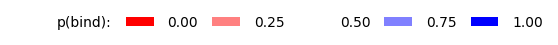

In [3]:
#@title **Display Structure** (Colored by Confidence)
rescale_by_max_pbind = False
use_native_coordinates = True
show_ligand = False

if rescale_by_max_pbind:
  preds_adj = pred_bind.copy() / pred_bind.max()
else:
  preds_adj = pred_bind.copy()

# replace plddt and coordinates of prediction
L = af_model._target_len
aux = copy.deepcopy(af_model.aux["all"])
aux["plddt"][:,:L] = preds_adj
if show_ligand:
  af_model.save_pdb("output.pdb",aux={"all":aux})
else:
  aux["atom_mask"][:,L:] = 0
  x = {k:[] for k in ["aatype",
                      "residue_index",
                      "atom_positions",
                      "atom_mask",
                      "b_factors"]}
  asym_id = []
  for i in range(af_model._target_len):
    for k in ["aatype","atom_mask"]: x[k].append(aux[k][0,i])
    if use_native_coordinates:
      x["atom_positions"].append(af_model._pdb["batch"]["all_atom_positions"][i])
    else:
      x["atom_positions"].append(aux["atom_positions"][0,i])
    x["residue_index"].append(af_model._pdb["idx"]["residue"][i])
    x["b_factors"].append(x["atom_mask"][-1] * aux["plddt"][0,i] * 100.0)
    asym_id.append(af_model._pdb["idx"]["chain"][i])
  x = {k:np.array(v) for k,v in x.items()}

  # fix the chains
  (n,resnum_) = (0,None)
  pdb_lines = []
  for line in protein.to_pdb(protein.Protein(**x)).splitlines():
    if line[:4] == "ATOM":
      resnum = int(line[22:22+5])
      if resnum_ is None: resnum_ = resnum
      if resnum != resnum_:
        n += 1
        resnum_ = resnum
      pdb_lines.append("%s%s%4i%s" % (line[:21],asym_id[n],resnum,line[26:]))
  with open("output.pdb","w") as handle:
    handle.write("\n".join(pdb_lines))

hbondCutoff = 4.0
view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',width=800,height=600)
pdb_str = open("output.pdb",'r').read()
view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
color_scheme = {'prop':'b','gradient': 'rwb','min':0,'max':100}
view.setStyle({'cartoon': {'colorscheme': color_scheme}})

# add sidechains
for i in range(af_model._target_len):
  c = af_model._pdb["idx"]["chain"][i]
  r = int(af_model._pdb["idx"]["residue"][i])
  p = pred_bind[i]
  if p > 0.5:
    view.addStyle({'and':[{'chain':c},{'resi':r},{'resn':["GLY","PRO"],'invert':True},{'atom':['C','O','N'],'invert':True}]},
                  {'stick':{'colorscheme':color_scheme,'radius':0.3}})
    view.addStyle({'and':[{'chain':c},{'resi':r},{'resn':"GLY"},{'atom':'CA'}]},
                  {'sphere':{'colorscheme':color_scheme,'radius':0.3}})
    view.addStyle({'and':[{'chain':c},{'resi':r},{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                  {'stick':{'colorscheme':color_scheme,'radius':0.3}})

view.setHoverable({}, True,
               '''function(atom,viewer,event,container){if(!atom.label){atom.label=viewer.addLabel(atom.chain+"/"+atom.resi+"/"+atom.resn+" "+(atom.b/100.0).toFixed(3),{position:atom,backgroundColor:'white',backgroundOpacity:0.75,borderColor:'black',borderThickness:2.0,fontColor:'black'});}}''',
               '''function(atom,viewer){if(atom.label){viewer.removeLabel(atom.label);delete atom.label;}}''')

view.zoomTo()
view.show()

def plot_plddt_legend(dpi=100):
  thresh = ['p(bind):','0.00','0.25','0.50','0.75','1.00']
  plt.figure(figsize=(1,0.1),dpi=dpi)
  ########################################
  for c in ["white","#FF0000","#FF8080","#FFFFFF","#8080FF","#0000FF"]:
    plt.bar(0, 0, color=c)
  plt.legend(thresh, frameon=False,
             loc='center', ncol=6,
             handletextpad=1,
             columnspacing=1,
             markerscale=0.5,)
  plt.axis(False)
  return plt
plot_plddt_legend().show()

In [4]:
#@title **Download Predictions**
from google.colab import files
os.system(f"zip -r output.zip output.pdb results.csv")
files.download(f'output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
#@title **Activation analysis** (optional)
pbind_cutoff = 0.5 # @param ["0.0", "0.5", "0.9"] {type:"raw"}
blosum_map = list("CSTAGPDEQNHRKMILVWYF")
cs_label_list = list("ACDEFGHIKLMNPQRSTVWY")

indices_A_Y_mapping = np.array([cs_label_list.index(letter) for letter in blosum_map])
pred_bind_aa_blosum = pred_bind_aa[:,indices_A_Y_mapping]
filt = pred_bind > pbind_cutoff
pred_bind_aa_blosum = pred_bind_aa_blosum[filt]
res_labels = np.array(af_model._pdb["idx"]["residue"])[filt]
chain_labels = np.array(af_model._pdb["idx"]["chain"])[filt]

fig = px.imshow(pred_bind_aa_blosum.T,
                labels=dict(x="positions", y="amino acids", color="pref"),
                y=blosum_map,
                x=[f"{y}_{x}" for x,y in zip(res_labels,chain_labels)],
                zmin=-1,
                zmax=1,
                template="simple_white",
                color_continuous_scale=["red", "white", "blue"],
              )
fig.show()

## 🔌 AF2Bind API mode (Colab GPU)

This adds an HTTP API so your NovoProtein app can call AF2Bind remotely.

**Flow**: start the API → get a public URL → your app sends POST requests.

> Tip: keep this tab open while using the API. Colab may disconnect.


In [ ]:
#@title Install API + tunnel deps
!pip -q install fastapi "uvicorn<0.30" python-multipart nest-asyncio
# Install cloudflared binary (the pip package doesn't include the actual binary)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

In [ ]:
#@title Configure API key (required)
# Put a long random string here. Your app must send the same key in header: x-api-key
API_KEY = "CHANGE_ME_TO_A_LONG_RANDOM_STRING"


In [ ]:
#@title AF2Bind runner function (no UI rendering)
import os, time, uuid, shutil, copy as pycopy
from pathlib import Path

def af2bind_run_to_files(
    target_pdb: str,
    target_chain: str = "A",
    mask_sidechains: bool = True,
    mask_sequence: bool = False,
    rescale_by_max_pbind: bool = False,
    use_native_coordinates: bool = True,
    show_ligand: bool = False,
):
  """Runs AF2Bind and writes results.csv + output.pdb.

  Requires that you already ran the original notebook cells that define:
  - get_pdb, clear_mem, mk_afdesign_model, af2bind
  and imported numpy/pandas/etc (the base notebook already does this).
  """

  # sanitize
  target_pdb = (target_pdb or "").replace(" ", "")
  target_chain = (target_chain or "A").replace(" ", "") or "A"

  # unique work dir per request
  job_id = str(uuid.uuid4())[:8]
  workdir = Path(f"/content/af2bind_api_jobs/{job_id}")
  workdir.mkdir(parents=True, exist_ok=True)

  # ---- (A) Run AF2Bind (based on the notebook's Run AF2BIND cell) ----
  pdb_filename = get_pdb(target_pdb)

  clear_mem()
  af_model = mk_afdesign_model(protocol="binder", debug=True)
  af_model.prep_inputs(
      pdb_filename=pdb_filename,
      chain=target_chain,
      binder_len=20,
      rm_target_sc=mask_sidechains,
      rm_target_seq=mask_sequence
  )

  # split residue index for binder chain
  r_idx = af_model._inputs["residue_index"][-20] + (1 + np.arange(20)) * 50
  af_model._inputs["residue_index"][-20:] = r_idx.flatten()

  af_model.set_seq("ACDEFGHIKLMNPQRSTVWY")
  af_model.predict(verbose=False)

  o = af2bind(af_model.aux["debug"]["outputs"], mask_sidechains=mask_sidechains)
  pred_bind = o["p_bind"].copy()

  # results.csv (same columns as notebook)
  labels = ["chain", "resi", "resn", "p(bind)"]
  data = []
  for i in range(af_model._target_len):
    c = af_model._pdb["idx"]["chain"][i]
    r = af_model._pdb["idx"]["residue"][i]
    a = aa_order.get(af_model._pdb["batch"]["aatype"][i], "X")
    p = float(pred_bind[i])
    data.append([c, r, a, p])

  df = pd.DataFrame(data, columns=labels)
  csv_path = workdir / "results.csv"
  df.to_csv(csv_path, index=False)

  # ---- (B) Build output.pdb (based on Display Structure cell, no 3Dmol) ----
  if rescale_by_max_pbind:
    preds_adj = pred_bind.copy() / (pred_bind.max() if pred_bind.max() != 0 else 1.0)
  else:
    preds_adj = pred_bind.copy()

  L = af_model._target_len
  aux = pycopy.deepcopy(af_model.aux["all"])
  aux["plddt"][:,:L] = preds_adj

  pdb_path = workdir / "output.pdb"

  if show_ligand:
    # save full complex
    af_model.save_pdb(str(pdb_path), aux={"all": aux})
  else:
    # remove binder from saved structure
    aux["atom_mask"][:, L:] = 0
    x = {k: [] for k in ["aatype", "residue_index", "atom_positions", "atom_mask", "b_factors"]}
    asym_id = []

    for i in range(af_model._target_len):
      for k in ["aatype", "atom_mask"]:
        x[k].append(aux[k][0, i])

      if use_native_coordinates:
        x["atom_positions"].append(af_model._pdb["batch"]["all_atom_positions"][i])
      else:
        x["atom_positions"].append(aux["atom_positions"][0, i])

      x["residue_index"].append(af_model._pdb["idx"]["residue"][i])
      x["b_factors"].append(x["atom_mask"][-1] * aux["plddt"][0, i] * 100.0)
      asym_id.append(af_model._pdb["idx"]["chain"][i])

    x = {k: np.array(v) for k, v in x.items()}

    # fix chain IDs
    (n, resnum_) = (0, None)
    pdb_lines = []
    for line in protein.to_pdb(protein.Protein(**x)).splitlines():
      if line[:4] == "ATOM":
        resnum = int(line[22:22+5])
        if resnum_ is None:
          resnum_ = resnum
        if resnum != resnum_:
          n += 1
          resnum_ = resnum
        pdb_lines.append("%s%s%4i%s" % (line[:21], asym_id[n], resnum, line[26:]))

    pdb_path.write_text("\n".join(pdb_lines))

  return {
    "job_id": job_id,
    "workdir": str(workdir),
    "results_csv_path": str(csv_path),
    "output_pdb_path": str(pdb_path),
  }


In [ ]:
#@title FastAPI server (in-notebook; uses your loaded AF2Bind code)
import nest_asyncio, asyncio, threading, traceback
from fastapi import FastAPI, Header, HTTPException
from pydantic import BaseModel
from pathlib import Path

nest_asyncio.apply()
app = FastAPI()

class AF2BindRequest(BaseModel):
  target_pdb: str
  target_chain: str = "A"
  mask_sidechains: bool = True
  mask_sequence: bool = False

@app.get("/health")
def health():
  return {"ok": True}

@app.post("/af2bind")
def af2bind_api(req: AF2BindRequest, x_api_key: str = Header(default="")):
  if x_api_key != API_KEY:
    raise HTTPException(status_code=401, detail="bad api key")

  t0 = time.time()
  try:
    out = af2bind_run_to_files(
      target_pdb=req.target_pdb,
      target_chain=req.target_chain,
      mask_sidechains=req.mask_sidechains,
      mask_sequence=req.mask_sequence,
    )
  except FileNotFoundError as e:
    # Structure not found in AlphaFold DB or RCSB
    raise HTTPException(status_code=400, detail=str(e))
  except Exception as e:
    # Log full traceback to Colab output for debugging
    traceback.print_exc()
    raise HTTPException(
      status_code=500,
      detail=f"AF2Bind prediction failed: {e}"
    )

  csv_text = Path(out["results_csv_path"]).read_text()
  pdb_text = Path(out["output_pdb_path"]).read_text()

  return {
    "job_id": out["job_id"],
    "seconds": round(time.time() - t0, 2),
    "results_csv": csv_text,
    "output_pdb": pdb_text,
  }

In [ ]:
#@title Start server + expose public URL (Cloudflare tunnel)
import uvicorn, subprocess, re, time, sys, asyncio

# Start uvicorn in a background thread with its own event loop
# (nest_asyncio only patches the main thread; background threads need explicit loop creation)
def _run_uvicorn():
  loop = asyncio.new_event_loop()
  asyncio.set_event_loop(loop)
  config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
  server = uvicorn.Server(config)
  loop.run_until_complete(server.serve())

server_thread = threading.Thread(target=_run_uvicorn, daemon=True)
server_thread.start()
time.sleep(2)

# Start cloudflared tunnel
cloudflared_proc = subprocess.Popen(
  ["cloudflared", "tunnel", "--url", "http://localhost:8000"],
  stdout=subprocess.PIPE,
  stderr=subprocess.STDOUT,
  text=True
)

public_url = None
start = time.time()
print("Finding public URL...")

while time.time() - start < 30:
  line = cloudflared_proc.stdout.readline()
  if not line:
    continue
  line = line.strip()
  if line:
    print(line)
  m = re.search(r"(https://[-\w]+\.trycloudflare\.com)", line)
  if m:
    public_url = m.group(1)
    break

print("\n✅ PUBLIC URL:", public_url)
print("Test: curl -s", f"{public_url}/health")

In [ ]:
#@title Example request (run after you have the PUBLIC URL)
# Fill in your URL printed above:
PUBLIC_URL = "PASTE_PUBLIC_URL_HERE"

# Example call from inside Colab:
import requests, json
payload = {"target_pdb":"Q6DG85","target_chain":"A","mask_sidechains":True,"mask_sequence":False}
r = requests.post(
  f"{PUBLIC_URL}/af2bind",
  headers={"x-api-key": API_KEY},
  json=payload,
  timeout=600
)
print("status:", r.status_code)
print(r.json().keys() if r.ok else r.text)
